# Vehicle price prediction using Linear Regression

# Business Requriement

Can we build a pricing model that predicts a vehicle's fair market price based on its specifications, usage history, and condition — enabling the dealership to flag underpriced/overpriced listings and identify which factors (age, mileage, accidents, brand) most strongly drive resale value?

**Price** of the car is the target value to predict

- Kaggle Dataset Link: https://www.kaggle.com/code/mandyreyes/automotive-price-prediction-lr 

# 1 Load and explore data

In [2]:
# import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Import the data

df = pd.read_csv('vehicle_price_prediction.csv')
df

,make,model,year,mileage,engine_hp,transmission,fuel_type,drivetrain,body_type,exterior_color,interior_color,owner_count,accident_history,seller_type,condition,trim,vehicle_age,mileage_per_year,brand_popularity,price
0,Volkswagen,Jetta,2016,183903,173,Manual,Electric,RWD,Sedan,Blue,Brown,5,NaN,Dealer,Excellent,EX,9,20433.666667,0.040054,7208.52
1,Lexus,RX,2010,236643,352,Manual,Gasoline,FWD,Sedan,Silver,Beige,5,Minor,Dealer,Good,LX,15,15776.200000,0.039921,6911.81
2,Subaru,Crosstrek,2016,103199,188,Automatic,Diesel,AWD,Sedan,Silver,Beige,5,NaN,Dealer,Excellent,Touring,9,11466.555556,0.040230,11915.63
3,Cadillac,Lyriq,2016,118889,338,Manual,Gasoline,AWD,SUV,Black,Gray,3,NaN,Private,Good,Base,9,13209.888889,0.039847,25984.79
4,Toyota,Highlander,2018,204170,196,Manual,Diesel,FWD,Sedan,Red,Brown,5,Minor,Dealer,Excellent,Sport,7,29167.142857,0.039627,8151.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,Jeep,Cherokee,2015,130407,176,Manual,Electric,FWD,SUV,Red,Black,2,NaN,Dealer,Excellent,Touring,10,13040.700000,0.040006,10928.88
999996,Dodge,Challenger,2013,276316,211,Manual,Gasoline,RWD,Coupe,Red,Beige,4,Minor,Dealer,Good,Sport,12,23026.333333,0.040035,1827.22
999997,Mercedes-Benz,E-Class,2023,3964,339,Automatic,Electric,AWD,SUV,White,Brown,2,NaN,Dealer,Good,Sport,2,1982.000000,0.039794,48882.42
999998,Volvo,XC90,2019,83674,311,Automatic,Gasoline,AWD,Wagon,Blue,Beige,2,NaN,Dealer,Excellent,Limited,6,13945.666667,0.039842,32195.91


In [4]:
df.shape # 1000000 rows × 20 columns

(1000000, 20)

In [5]:
df.head(10)

,make,model,year,mileage,engine_hp,transmission,fuel_type,drivetrain,body_type,exterior_color,interior_color,owner_count,accident_history,seller_type,condition,trim,vehicle_age,mileage_per_year,brand_popularity,price
0,Volkswagen,Jetta,2016,183903,173,Manual,Electric,RWD,Sedan,Blue,Brown,5,NaN,Dealer,Excellent,EX,9,20433.666667,0.040054,7208.52
1,Lexus,RX,2010,236643,352,Manual,Gasoline,FWD,Sedan,Silver,Beige,5,Minor,Dealer,Good,LX,15,15776.200000,0.039921,6911.81
2,Subaru,Crosstrek,2016,103199,188,Automatic,Diesel,AWD,Sedan,Silver,Beige,5,NaN,Dealer,Excellent,Touring,9,11466.555556,0.040230,11915.63
3,Cadillac,Lyriq,2016,118889,338,Manual,Gasoline,AWD,SUV,Black,Gray,3,NaN,Private,Good,Base,9,13209.888889,0.039847,25984.79
4,Toyota,Highlander,2018,204170,196,Manual,Diesel,FWD,Sedan,Red,Brown,5,Minor,Dealer,Excellent,Sport,7,29167.142857,0.039627,8151.30
5,Land Rover,Defender,2021,44907,479,Manual,Diesel,RWD,SUV,Silver,Black,5,NaN,Dealer,Excellent,Touring,4,11226.750000,0.040133,59490.99
6,Mazda,Mazda3,2018,129770,160,Automatic,Diesel,FWD,Hatchback,White,Beige,1,NaN,Dealer,Good,EX,7,18538.571429,0.040247,10822.61
7,Volkswagen,Atlas,2022,29146,172,Automatic,Gasoline,RWD,SUV,White,Black,5,NaN,Dealer,Excellent,Limited,3,9715.333333,0.040054,26934.78
8,Ram,2500,2015,169165,197,Automatic,Electric,RWD,Pickup Truck,Gray,Black,3,NaN,Private,Good,Sport,10,16916.500000,0.040148,11430.65
9,Chrysler,300,2025,5081,198,Automatic,Diesel,FWD,Sedan,Red,Beige,1,NaN,Private,Good,Sport,1,5081.000000,0.040059,30576.77


In [6]:
# check for null values

df.isna().sum()

# only accident_history has null values

make                     0
model                    0
year                     0
mileage                  0
engine_hp                0
transmission             0
fuel_type                0
drivetrain               0
body_type                0
exterior_color           0
interior_color           0
owner_count              0
accident_history    750133
seller_type              0
condition                0
trim                     0
vehicle_age              0
mileage_per_year         0
brand_popularity         0
price                    0
dtype: int64

In [7]:
df.describe()

,year,mileage,engine_hp,owner_count,vehicle_age,mileage_per_year,brand_popularity,price
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,2017.453816,112660.126464,235.664301,3.477846,7.585987,14540.674200,0.040001,20329.302593
std,3.902285,72088.236925,93.614773,1.544856,3.829534,6108.901522,0.000234,13644.467189
min,2000.000000,500.000000,90.000000,1.000000,1.000000,33.333333,0.039318,1500.000000
25%,2015.000000,57654.000000,162.000000,2.000000,5.000000,10487.633523,0.039842,10324.527500
50%,2018.000000,103331.000000,215.000000,4.000000,7.000000,14688.118056,0.040022,17864.740000
75%,2020.000000,157865.000000,300.000000,5.000000,10.000000,18685.942308,0.040148,27601.402500
max,2025.000000,300000.000000,581.000000,5.000000,25.000000,55391.000000,0.040484,93422.090000


In [8]:
df.dtypes

make                    str
model                   str
year                  int64
mileage               int64
engine_hp             int64
transmission            str
fuel_type               str
drivetrain              str
body_type               str
exterior_color          str
interior_color          str
owner_count           int64
accident_history        str
seller_type             str
condition               str
trim                    str
vehicle_age           int64
mileage_per_year    float64
brand_popularity    float64
price               float64
dtype: object

In [9]:
# How many unique cars the compay has
unique_cars = df['make'].unique()
unique_cars

# 25 unique cars the company has

<StringArray>
[   'Volkswagen',         'Lexus',        'Subaru',      'Cadillac',
        'Toyota',    'Land Rover',         'Mazda',           'Ram',
      'Chrysler',           'GMC',         'Volvo',          'Audi',
     'Chevrolet',         'Tesla',       'Hyundai',          'Ford',
       'Porsche',         'Acura',        'Nissan',           'Kia',
          'Jeep',           'BMW',         'Dodge', 'Mercedes-Benz',
         'Honda']
Length: 25, dtype: str

In [10]:
# How many unique transmission
unique_transmission = df['transmission'].unique()
unique_transmission

# 2 unique transmission

<StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str

In [11]:
# How many unique fuel types
unique_fuels = df['fuel_type'].unique()
unique_fuels

# 3 types of Fuel

<StringArray>
['Electric', 'Gasoline', 'Diesel']
Length: 3, dtype: str

In [12]:
# How many drivetrain and body type

unique_drive =  df['drivetrain'].unique()
print("Unique Drive wheel")
print(unique_drive)
print()

print("Unique body types of vehicle")
unique_body = df['body_type'].unique()
print(unique_body)

Unique Drive wheel
<StringArray>
['RWD', 'FWD', 'AWD']
Length: 3, dtype: str

Unique body types of vehicle
<StringArray>
['Sedan', 'SUV', 'Hatchback', 'Pickup Truck', 'Coupe', 'Minivan', 'Wagon']
Length: 7, dtype: str


In [13]:
df[df['price']<=2000]['price'].value_counts().head(20)

# There are many rows which holds the value of 1500$. This might be synthetic data added or clamped values when the data was generated

price
1500.00    46984
1645.45        3
1773.15        3
1605.36        3
1826.21        3
1907.80        3
1874.80        3
1521.77        3
1587.35        3
1717.16        3
1997.79        3
1523.12        3
1800.20        3
1545.10        3
1646.86        3
1913.31        3
1785.80        3
1927.80        3
1548.03        3
1574.70        3
Name: count, dtype: int64

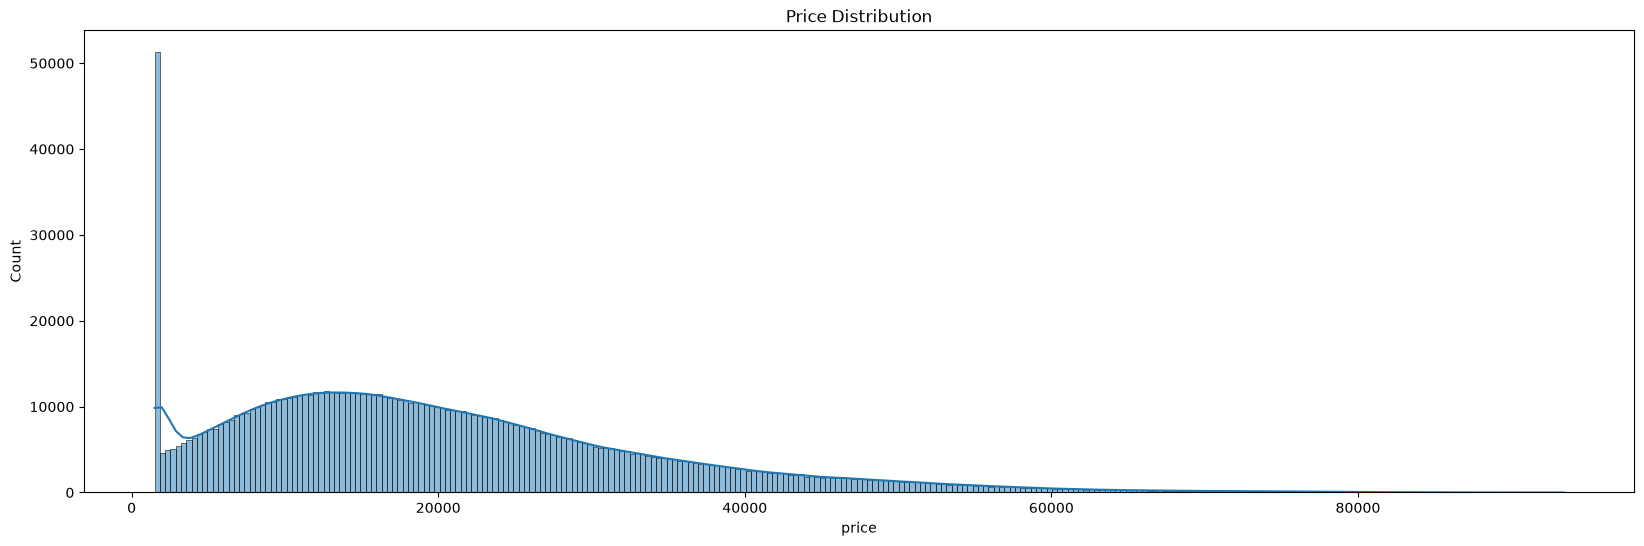

In [14]:
# Before dropping rows which has value of 1500

df['price'].skew()

plt.figure(figsize=(20, 6))
sns.histplot(df['price'], kde=True)
plt.title('Price Distribution')
plt.show()

In [15]:
# Drop the rows where the Price = 1500$, as this will affect the decision making process of the model and the model will get skewed. Almost 4.7% of data has price=1500, Dropping it won't affect much
df = df[df['price'] != 1500.00].reset_index(drop=True)


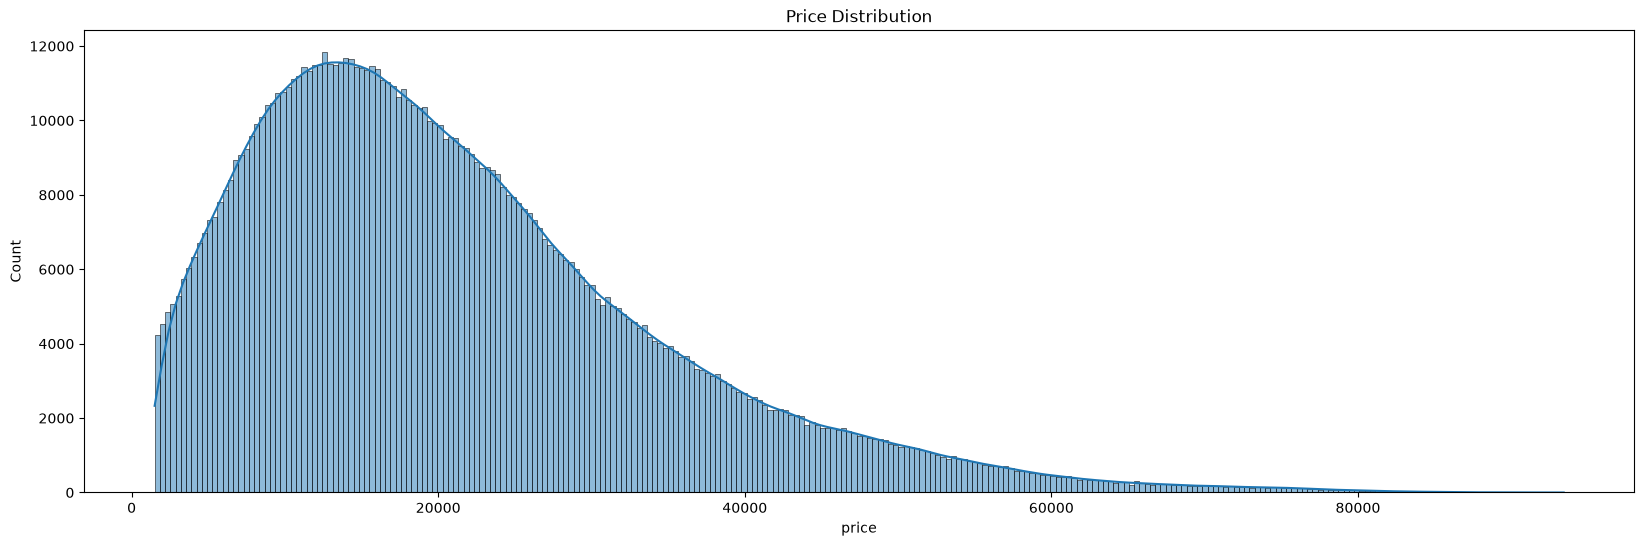

In [16]:
df['price'].skew()

plt.figure(figsize=(20, 6))
sns.histplot(df['price'], kde=True)
plt.title('Price Distribution')
plt.show()

# Price is right-skewed 
# The chart shows the datapoints of 1M Car prices spread across different range. 
# Most are between 10k-20k dollars. Very-few above 60k  

# 2 Feature engineering

In [17]:
# Replace Nan in accidents with "Unknown"
df['accident_history'] = df['accident_history'].fillna('Unknown')
df.head()

,make,model,year,mileage,engine_hp,transmission,fuel_type,drivetrain,body_type,exterior_color,interior_color,owner_count,accident_history,seller_type,condition,trim,vehicle_age,mileage_per_year,brand_popularity,price
0,Volkswagen,Jetta,2016,183903,173,Manual,Electric,RWD,Sedan,Blue,Brown,5,Unknown,Dealer,Excellent,EX,9,20433.666667,0.040054,7208.52
1,Lexus,RX,2010,236643,352,Manual,Gasoline,FWD,Sedan,Silver,Beige,5,Minor,Dealer,Good,LX,15,15776.200000,0.039921,6911.81
2,Subaru,Crosstrek,2016,103199,188,Automatic,Diesel,AWD,Sedan,Silver,Beige,5,Unknown,Dealer,Excellent,Touring,9,11466.555556,0.040230,11915.63
3,Cadillac,Lyriq,2016,118889,338,Manual,Gasoline,AWD,SUV,Black,Gray,3,Unknown,Private,Good,Base,9,13209.888889,0.039847,25984.79
4,Toyota,Highlander,2018,204170,196,Manual,Diesel,FWD,Sedan,Red,Brown,5,Minor,Dealer,Excellent,Sport,7,29167.142857,0.039627,8151.30


In [18]:
# Correlation analysis
numeric_cols = df.select_dtypes(include=['float64','int64']).columns
numeric_cols

Index(['year', 'mileage', 'engine_hp', 'owner_count', 'vehicle_age',
       'mileage_per_year', 'brand_popularity', 'price'],
      dtype='str')

In [19]:
# Find the correlation of Price with all the numeric columns and check which column influences the Price more

correlation = df[numeric_cols].corr()['price'].sort_values(ascending=False)
correlation

price               1.000000
engine_hp           0.640709
year                0.629913
brand_popularity    0.061951
mileage_per_year   -0.183008
owner_count        -0.422484
mileage            -0.570445
vehicle_age        -0.627624
Name: price, dtype: float64

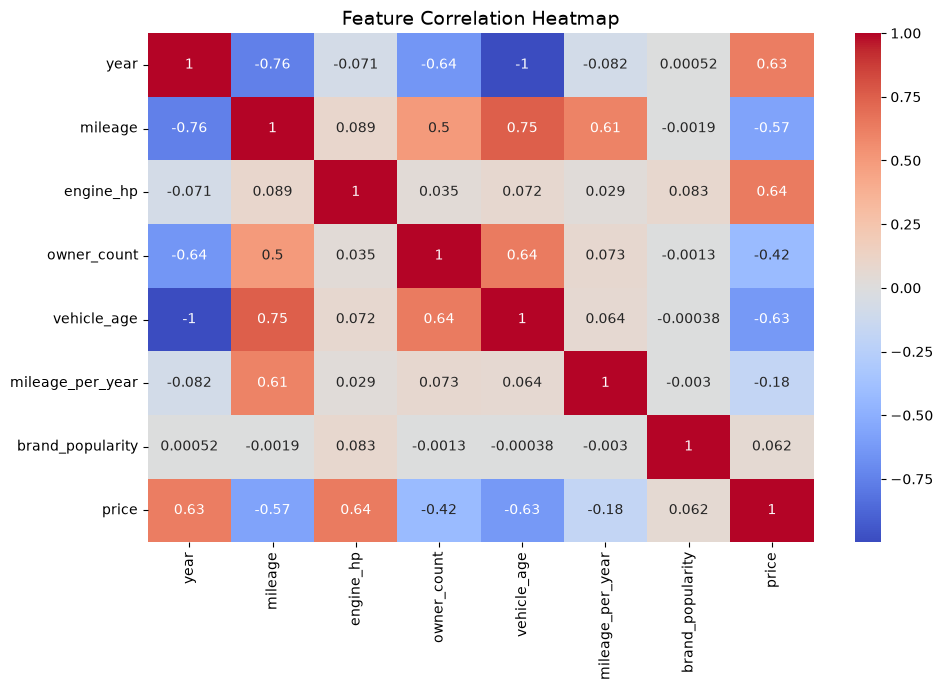

In [20]:
# heat map of all correlation

plt.figure(figsize=(10,7))
correaltion = df[numeric_cols].corr()
sns.heatmap(correaltion, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

In [21]:
# Compute Variance Inflation Factor (VIF) with each feature for Multicollinearity

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = df[['year', 'engine_hp', 'brand_popularity', 'mileage_per_year', 'owner_count', 'mileage', 'vehicle_age']]

# Constant for accurate regression calculation
X_with_constant = add_constant(X)

# Dataframe for vif results
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns

# Calculate VIF for each feature
vif_data['VIF'] = [variance_inflation_factor(X_with_constant.values, i) for i in range (1,X_with_constant.shape[1])]
(vif_data)


,Feature,VIF
0,year,559.877252
1,engine_hp,1.016892
2,brand_popularity,1.007002
3,mileage_per_year,5.148527
4,owner_count,1.709553
5,mileage,10.497624
6,vehicle_age,610.017843


In [22]:
# Dropping columns with high Multicollinearity

# Dropping "year" as "vehicel_age" is more important for re-sale price.
# Dropping "mileage_per_year" as "mileage" is more important for re-sale price.

df.drop(columns=['year', 'mileage_per_year'], inplace=True)


In [23]:
# Re check the updated VIF with other columns

X = df[['engine_hp', 'brand_popularity', 'owner_count', 'mileage', 'vehicle_age']]

# Constant for accurate regression calculation
X_with_constant = add_constant(X)

# Dataframe for vif results
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns

# Calculate VIF for each feature
vif_data['VIF'] = [variance_inflation_factor(X_with_constant.values, i) for i in range (1,X_with_constant.shape[1])]
(vif_data)

# This confirms there's no Multicollienarity now 

,Feature,VIF
0,engine_hp,1.015385
1,brand_popularity,1.006995
2,owner_count,1.695710
3,mileage,2.326751
4,vehicle_age,2.957987


# 3 Encoding

In [24]:
df.columns.tolist()

['make',
 'model',
 'mileage',
 'engine_hp',
 'transmission',
 'fuel_type',
 'drivetrain',
 'body_type',
 'exterior_color',
 'interior_color',
 'owner_count',
 'accident_history',
 'seller_type',
 'condition',
 'trim',
 'vehicle_age',
 'brand_popularity',
 'price']

In [25]:
df.dtypes

make                    str
model                   str
mileage               int64
engine_hp             int64
transmission            str
fuel_type               str
drivetrain              str
body_type               str
exterior_color          str
interior_color          str
owner_count           int64
accident_history        str
seller_type             str
condition               str
trim                    str
vehicle_age           int64
brand_popularity    float64
price               float64
dtype: object

In [26]:
# Low Cardinality -> Performing One-hot Encoding 

df_encoded = pd.get_dummies(df,columns= ['transmission', 'fuel_type', 'drivetrain', 'body_type', 'seller_type', 'accident_history', 'condition'], drop_first = True, dtype=int) # To avoid "dummy variable trap"
df_encoded


,make,model,mileage,engine_hp,exterior_color,interior_color,owner_count,trim,vehicle_age,brand_popularity,...,body_type_Minivan,body_type_Pickup Truck,body_type_SUV,body_type_Sedan,body_type_Wagon,seller_type_Private,accident_history_Minor,accident_history_Unknown,condition_Fair,condition_Good
0,Volkswagen,Jetta,183903,173,Blue,Brown,5,EX,9,0.040054,...,0,0,0,1,0,0,0,1,0,0
1,Lexus,RX,236643,352,Silver,Beige,5,LX,15,0.039921,...,0,0,0,1,0,0,1,0,0,1
2,Subaru,Crosstrek,103199,188,Silver,Beige,5,Touring,9,0.040230,...,0,0,0,1,0,0,0,1,0,0
3,Cadillac,Lyriq,118889,338,Black,Gray,3,Base,9,0.039847,...,0,0,1,0,0,1,0,1,0,1
4,Toyota,Highlander,204170,196,Red,Brown,5,Sport,7,0.039627,...,0,0,0,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
953011,Jeep,Cherokee,130407,176,Red,Black,2,Touring,10,0.040006,...,0,0,1,0,0,0,0,1,0,0
953012,Dodge,Challenger,276316,211,Red,Beige,4,Sport,12,0.040035,...,0,0,0,0,0,0,1,0,0,1
953013,Mercedes-Benz,E-Class,3964,339,White,Brown,2,Sport,2,0.039794,...,0,0,1,0,0,0,0,1,0,1
953014,Volvo,XC90,83674,311,Blue,Beige,2,Limited,6,0.039842,...,0,0,0,0,1,0,0,1,0,0


In [27]:
df_encoded.dtypes

make                            str
model                           str
mileage                       int64
engine_hp                     int64
exterior_color                  str
interior_color                  str
owner_count                   int64
trim                            str
vehicle_age                   int64
brand_popularity            float64
price                       float64
transmission_Manual           int64
fuel_type_Electric            int64
fuel_type_Gasoline            int64
drivetrain_FWD                int64
drivetrain_RWD                int64
body_type_Hatchback           int64
body_type_Minivan             int64
body_type_Pickup Truck        int64
body_type_SUV                 int64
body_type_Sedan               int64
body_type_Wagon               int64
seller_type_Private           int64
accident_history_Minor        int64
accident_history_Unknown      int64
condition_Fair                int64
condition_Good                int64
dtype: object

# Train-Test Split for Target Encoding

In [28]:
# High- cardinality -> Perform target encoding
from sklearn.model_selection import train_test_split

X = df_encoded.drop('price',axis=1)
y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)   #  this line will split the data. X_train will have 80% of data y_train will have 80% of price column data. Rest with X_test, y_test

make_means = y_train.groupby(X_train['make']).mean()
X_train['make'] = X_train['make'].map(make_means)
X_test['make'] = X_test['make'].map(make_means)


In [29]:
model_means = y_train.groupby(X_train['model']).mean()
X_train['model'] = X_train['model'].map(model_means)
X_test['model'] = X_test['model'].map(model_means)

In [30]:
trim_means = y_train.groupby(X_train['trim']).mean()
X_train['trim'] = X_train['trim'].map(trim_means)
X_test['trim'] = X_test['trim'].map(trim_means)

In [31]:
exterior_color_means = y_train.groupby(X_train['exterior_color']).mean()
X_train['exterior_color'] = X_train['exterior_color'].map(exterior_color_means)
X_test['exterior_color'] = X_test['exterior_color'].map(exterior_color_means)

In [32]:
interior_color_means = y_train.groupby(X_train['interior_color']).mean()
X_train['interior_color'] = X_train['interior_color'].map(interior_color_means)
X_test['interior_color'] = X_test['interior_color'].map(interior_color_means)

In [33]:
X_train.dtypes

make                        float64
model                       float64
mileage                       int64
engine_hp                     int64
exterior_color              float64
interior_color              float64
owner_count                   int64
trim                        float64
vehicle_age                   int64
brand_popularity            float64
transmission_Manual           int64
fuel_type_Electric            int64
fuel_type_Gasoline            int64
drivetrain_FWD                int64
drivetrain_RWD                int64
body_type_Hatchback           int64
body_type_Minivan             int64
body_type_Pickup Truck        int64
body_type_SUV                 int64
body_type_Sedan               int64
body_type_Wagon               int64
seller_type_Private           int64
accident_history_Minor        int64
accident_history_Unknown      int64
condition_Fair                int64
condition_Good                int64
dtype: object

# 4 Feature Scaling

In [34]:
# Use ZSCORE to perform feature engineering -- StandardScaler uses Zscore at the backend

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit and transform on x_train - beacause (fit) learns mean and std & transform applies it on each score
X_train_scaled_data = scaler.fit_transform(X_train)

# only transform on test data - because you dont "re-learn" via "fit". Use the same mean and std from training data
X_test_scaled_data = scaler.transform(X_test)

# fit_transform on train — learns mean/std from train only. transform on test — applies same learned parameters. Never fit_transform on test.


In [35]:
X_train_scaled_data

array([[ 0.3412561 ,  0.34110354,  0.46621606, ...,  0.57663541,
        -0.33280309,  1.00160409],
       [-0.32687077, -0.33228653, -0.85136309, ...,  0.57663541,
         3.00477983, -0.99839847],
       [-1.14177483, -1.14342714, -1.57817212, ...,  0.57663541,
        -0.33280309,  1.00160409],
       ...,
       [ 0.3412561 ,  0.34110354, -0.98059929, ...,  0.57663541,
        -0.33280309, -0.99839847],
       [-1.07237079, -1.07156135, -0.68694153, ...,  0.57663541,
        -0.33280309, -0.99839847],
       [-0.4651633 , -0.47950899, -1.26476065, ...,  0.57663541,
        -0.33280309, -0.99839847]], shape=(762412, 26))

In [36]:
X_test_scaled_data

array([[-0.87444753, -0.8570487 , -0.20863673, ...,  0.57663541,
        -0.33280309, -0.99839847],
       [ 2.06309245,  2.07132243, -0.62600633, ...,  0.57663541,
        -0.33280309,  1.00160409],
       [-0.25605241, -0.25503209,  2.11443413, ...,  0.57663541,
        -0.33280309, -0.99839847],
       ...,
       [-0.25605241, -0.25320867, -1.08959477, ...,  0.57663541,
        -0.33280309, -0.99839847],
       [-0.25605241, -0.25503209, -1.59780409, ...,  0.57663541,
        -0.33280309,  1.00160409],
       [-0.54006258, -0.54268312,  0.93184379, ...,  0.57663541,
        -0.33280309, -0.99839847]], shape=(190604, 26))

# 5 Train the model on Linear Regression

In [37]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_scaled_data, y_train)
print("Model training complete.")
print("Number of features used:", X_train_scaled_data.shape[1])

Model training complete.
Number of features used: 26


In [38]:
model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](26,)","[ 7091.54, 518.22,-3774.15,..., 2397.49, -951.54, -535.73]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.126e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,26
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,26
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](26,)","[1545.04,1301.68,1193.09,..., 307.41, 229.16, 6.92]"


# 6 Interpret the Coefficients

In [39]:
coef_df = pd.DataFrame(model.coef_, X_train.columns, columns=['Coeffiecients'])
coef_df

,Coeffiecients
make,7091.541818
model,518.217953
mileage,-3774.152722
engine_hp,2100.612944
exterior_color,5.575829
interior_color,6.826873
owner_count,-188.531656
trim,6.307851
vehicle_age,-6081.521964
brand_popularity,-59.572506


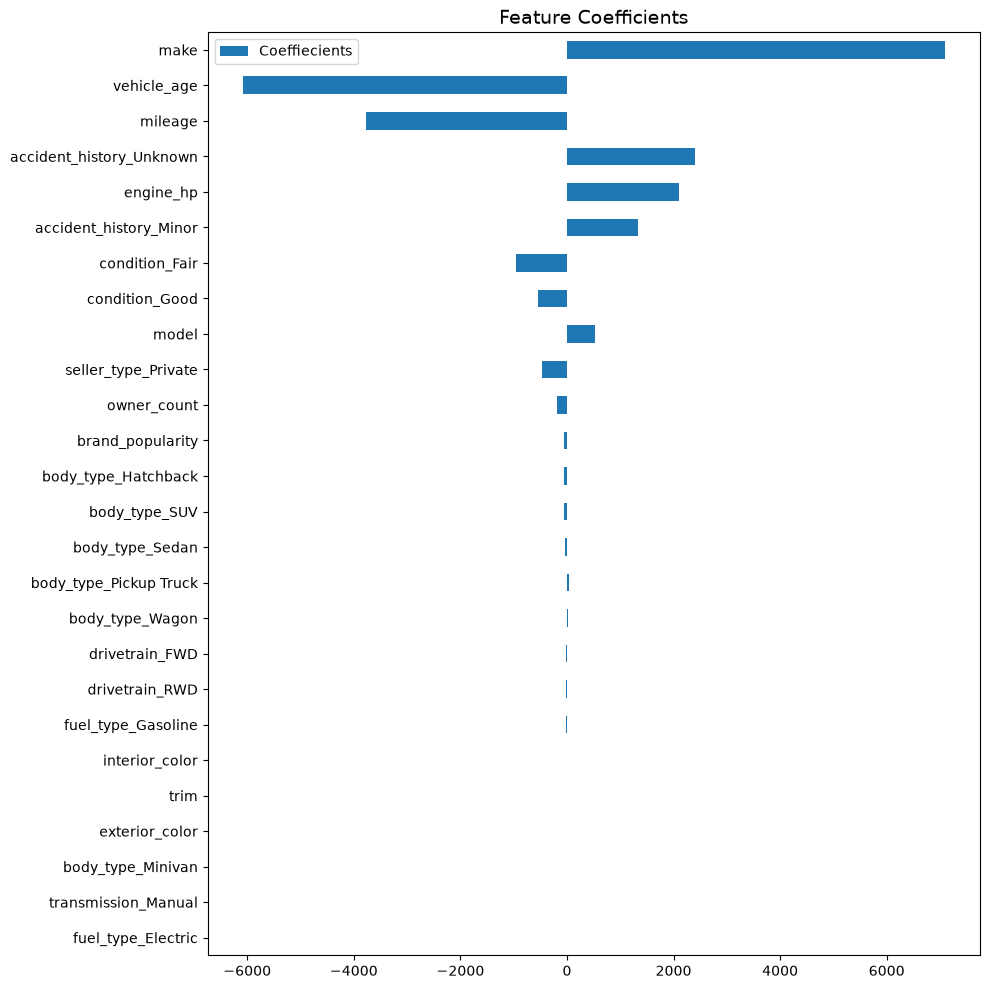

In [40]:
# Visualise the coefficients as bar chart - Identifying which factors drive the car price more or less
fig, ax = plt.subplots(figsize=(10, 10))
coef_df.reindex(coef_df['Coeffiecients'].abs().sort_values(ascending=True).index).plot(kind='barh', ax=ax)

plt.title("Feature Coefficients", fontsize=14)
plt.tight_layout()
plt.show()

# 7 Actual vs Predicted

In [41]:
y_pred = model.predict(X_test_scaled_data)
y_pred

array([ 8272.32653345, 39378.16287174,  2685.68719781, ...,
       29396.53570474, 35551.3507534 , 17381.56242704], shape=(190604,))

In [42]:
# Compare Actual Salary(y_test) with Predictated(y_pred)

results = pd.DataFrame({
    'Actual Price': y_test,
    'Predictated Price': y_pred,
    'Residual': y_test - y_pred
})
(results).reset_index(drop=True)   # drops the old index num and starts with new

,Actual Price,Predictated Price,Residual
0,9283.31,8272.326533,1010.983467
1,36037.94,39378.162872,-3340.222872
2,3992.92,2685.687198,1307.232802
3,21521.23,22292.417402,-771.187402
4,9991.72,10838.828979,-847.108979
...,...,...,...
190599,4153.82,-475.275709,4629.095709
190600,35129.29,32369.089527,2760.200473
190601,28175.77,29396.535705,-1220.765705
190602,37488.42,35551.350753,1937.069247


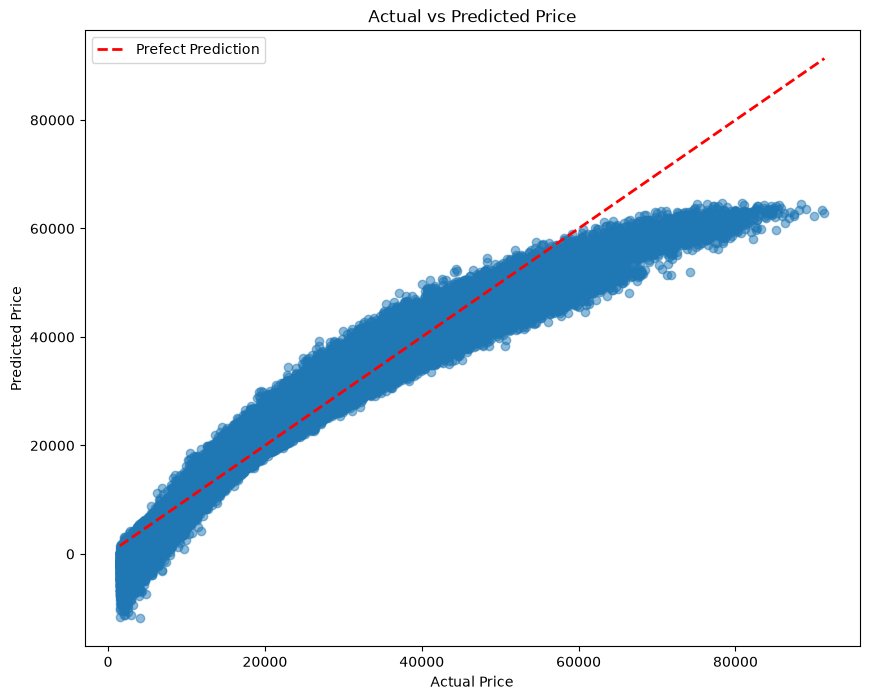

In [43]:
# Scatter plot for to plot the Residual between Actual Pirce and Predictaed price

plt.figure(figsize=(10,8))

plt.scatter(y_test, y_pred, alpha=0.5)

min_val = y_test.min()
max_val = y_test.max()

plt.plot([min_val, max_val], [min_val, max_val], linewidth=2, color='red', linestyle='--', label='Prefect Prediction')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.legend()
plt.title("Actual vs Predicted Price")
plt.show()

# Dots ON the red line: perfect prediction — predicted price = actual price.
# Dots ABOVE the line: model overpredicted — said the car costs more than it actually does.
# Dots BELOW the line: model underpredicted — said the car costs less than it actually does.
# Dots CLOSE to the line: small error, good prediction.
# Dots FAR from the line: large error, bad prediction.

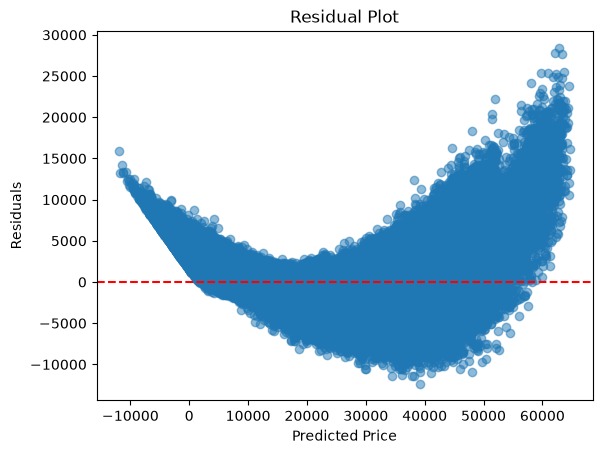

In [44]:
# Check for Homoscedastic usign scatter plot (y_pred vs Residual)


plt.scatter(y_pred, results['Residual'], alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

# 8 Evaluate the Model score

In [45]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)

print("=" * 45)
print("         Model Evaluation Summary")
print("=" * 45)

print(f"R2 Score: {round(r2,4)} ({round(r2*100, 1)}% variance explained)")
print(f"RMSE: ${round(rmse/1000, 2)} thousands")
print(f"MAE: ${round(mae/1000, 2)} thousands")
print("=" * 45)

         Model Evaluation Summary
R2 Score: 0.9517 (95.2% variance explained)
RMSE: $2.93 thousands
MAE: $2.07 thousands


- R² (R-squared): What % of price variation the model can successfully explains. Model account for R² = 95.17% of why prices differ between cars
- MAE (Mean Absolute Error): MAE: 2.07 thousands dollars, means on average the predictions missess by actual price by about 2.07k dollars
- RMSE (Root Mean Squared Error): Similar to MAE, but punishes large error heavily. There are some predictions with larger errors pulling the average up

# Predict For new cars

In [73]:
new_car = pd.DataFrame([{
    'make': 'Maruti',
    'model': 'Swift',
    'mileage': 7999,
    'engine_hp': 100,
    'transmission': 'Manual',
    'fuel_type': 'Gasoline',
    'drivetrain': 'FWD',
    'body_type': 'Minivan',
    'exterior_color': 'White',
    'interior_color': 'Black',
    'owner_count': 3,
    'accident_history': 'Unknown',
    'seller_type': 'Private',
    'condition': 'Good',
    'trim': 'Base',
    'vehicle_age': 3,
    'brand_popularity': 0.05
}])

In [74]:
# One-hot encode
new_car_encoded = pd.get_dummies(new_car, columns=['transmission','fuel_type','drivetrain','body_type','seller_type','accident_history','condition'], drop_first=True, dtype=int)
new_car_encoded = new_car_encoded.reindex(columns=X_train.columns, fill_value=0)
new_car_encoded

,make,model,mileage,engine_hp,exterior_color,interior_color,owner_count,trim,vehicle_age,brand_popularity,...,body_type_Minivan,body_type_Pickup Truck,body_type_SUV,body_type_Sedan,body_type_Wagon,seller_type_Private,accident_history_Minor,accident_history_Unknown,condition_Fair,condition_Good
0,Maruti,Swift,7999,100,White,Black,3,Base,3,0.05,...,0,0,0,0,0,0,0,0,0,0


In [75]:
new_car_encoded['make'] = new_car['make'].map(make_means).fillna(y_train.mean())
new_car_encoded['model'] = new_car['model'].map(model_means).fillna(y_train.mean())
new_car_encoded['trim'] = new_car['trim'].map(trim_means).fillna(y_train.mean())
new_car_encoded['exterior_color'] = new_car['exterior_color'].map(exterior_color_means).fillna(y_train.mean())
new_car_encoded['interior_color'] = new_car['interior_color'].map(interior_color_means).fillna(y_train.mean())

new_car_encoded

,make,model,mileage,engine_hp,exterior_color,interior_color,owner_count,trim,vehicle_age,brand_popularity,...,body_type_Minivan,body_type_Pickup Truck,body_type_SUV,body_type_Sedan,body_type_Wagon,seller_type_Private,accident_history_Minor,accident_history_Unknown,condition_Fair,condition_Good
0,21256.370155,21256.370155,7999,100,21294.140452,21293.1182,3,21293.074658,3,0.05,...,0,0,0,0,0,0,0,0,0,0


In [76]:
new_car_scaled = scaler.transform(new_car_encoded)
predicted_price = model.predict(new_car_scaled)[0]
print(f"Predicted Price: ${predicted_price:,.2f}")

Predicted Price: $24,831.93
